# Homogenisation of a microscale RVE, with random rectangular voids.
*By James Baxter Chapman and Joshua Montgomery*
$$
$$
Computational homogenisation transforms a hetergeneous microstructure into a simple effective stiffness tensor. In this session, we will consider a solid with random rectangular voids, occupying a periodic domain $\Omega = [0, L]^3$, known as a representative volume element, or RVE. 

The any field $\mathbf{f}$, the volume average is
$$
\langle \mathbf{f} \rangle = \frac{1}{\Omega}\int_{\Omega}\mathbf{f(x)}d\Omega. \tag{1}
$$
For linear elasticity, the goal is to homogenise for an effective stiffness $\mathbb{C}^{\text{eff}}$ such that
$$
\langle \mathbf{\sigma} \rangle = \mathbb{C}^{\text{eff}} : \langle \mathbf{\varepsilon} \rangle \tag{2}
$$
##### The strain decomposition

The RVE must be periodic, which presents a challenge when solving for the total displacement: the macroscopic stretch is inherently non-periodic, and the system lacks Dirichlet boundary conditions to prevent rigid body translations. To resolve this, we decompose the microscopic displacement:
$$
u(\mathbf{x}) = \underbrace{\bar{\mathbf{E}} \cdot \mathbf{x}}_{\text{Macro}} + \underbrace{\mathbf{w}(\mathbf{x})}_{\text{Fluctuation}} \tag{3}
$$
By isolating a non-periodic linear part ($\bar{\mathbf{E}} \cdot \mathbf{x}$) and solving for the fluctuation $\mathbf{w(x)}$, which is purely periodic, we can effectively map the solution across the boundaries and restore the stability of the system.

Following this displacement split, the microscopic strain tensor $\varepsilon(\mathbf{u})$ is defined as the symmetric gradient of the total displacement. Due to the linearity of the gradient operator, the strain can also be decomposed into macroscopic and microscopic components:
$$
\varepsilon(\mathbf{u}) = \underbrace{\bar{\mathbf{E}}}_{\text{Macro Strain}} + \underbrace{\varepsilon(\mathbf{w})}_{\text{Fluctuation Strain}} \tag{4}
$$
Here, $\bar{\mathbf{E}}$ represents the uniform, macroscale prescribed strain applied to the RVE, while $\varepsilon(\mathbf{w}) = \text{sym}(\nabla \mathbf{w})$ accounts for the local strain variations caused by the internal geometry (such as pores or inclusions). This decomposition is central to the homogenisation process: while the fluctuation strain $\varepsilon(\mathbf{w})$ varies significantly across the RVE, its volume average is zero due to the periodicity of $\mathbf{w}$. Consequently, the volume average of the total microscopic strain is exactly equal to the macroscopic strain $\bar{\mathbf{E}}$. This allows us to probe the RVE with a known average strain and calculate the resulting average stress to identify the effective material properties.

##### The governing equilibrium equation

To find the fluctuation field $\mathbf{w}(\mathbf{x})$, we enforce the condition of static equilibrium within the RVE. In the absence of body forces, the divergence of the Cauchy stress tensor $\sigma$ must vanish:
$$
\nabla \cdot \sigma = 0 \tag{5}
$$
By applying the local constitutive law (Hooke’s Law) and substituting our decomposed strain, we express the stress in terms of the macroscopic and fluctuation components:
$$
\nabla \cdot \left( \mathbb{C} : (\bar{\mathbf{E}} + \varepsilon(\mathbf{w})) \right) = 0 \tag{6}
$$
Rearranging the terms to isolate the unknown fluctuation on the left-hand side, we obtain the governing equation solved by the finite element routine:
$$
\underbrace{\nabla \cdot (\mathbb{C} : \varepsilon(\mathbf{w}))}_{\text{Internal Stiffness}} = \underbrace{-\nabla \cdot (\mathbb{C} : \bar{\mathbf{E}})}_{\text{Mismatch Force}} \tag{7}
$$
In this form, the macroscopic strain $\bar{\mathbf{E}}$ acts as an internal body force. Because the RVE is heterogeneous (containing solid and void regions), a uniform macro-strain creates a 'mismatch' in stress at the boundaries of the pores. The solver calculates the fluctuation $\mathbf{w}$ required to redistribute these stresses until the entire system reaches a state of equilibrium.


##### Volume averaging and the effective stiffness matrix

Once the equilibrium fluctuation field $\mathbf{w}$ is determined for a given macroscopic strain $\bar{\mathbf{E}}$, the corresponding macroscopic stress $\bar{\sigma}$ is calculated by taking the volume average of the microscopic stress field over the entire RVE:
$$
\bar{\sigma} = \langle \sigma \rangle = \frac{1}{\Omega} \int_{\Omega} \sigma(\mathbf{x}) \, d\Omega \tag{8}
$$
The effective stiffness tensor $\mathbb{C}_{eff}$—the $6 \times 6$ matrix in Voigt notation—is the linear mapping that relates this average stress to the prescribed average strain:
$$
\bar{\sigma} = \mathbb{C}_{eff} : \bar{\mathbf{E}} \tag{9}
$$
By sequentially applying six independent unit strain cases (three axial and three shear), we probe the RVE to populate the individual components of $\mathbb{C}_{eff}$. This homogenised tensor now represents the mechanical properties of a 'substitute' uniform material that behaves identically to the complex, porous structure on a macroscopic scale.

##### Finite Element Implementation

This notebook uses the python library NGSolve for use of the Finite Element Method.


In [51]:
try:
    from ngsolve import *
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/ngsolve-install-release-real.sh" -O "/tmp/ngsolve-install.sh" && bash "/tmp/ngsolve-install.sh"
    from ngsolve import *

import random
from netgen.occ import *
import numpy as np
import matplotlib.pyplot as plt

##### Geometry Generation

We will use the example of randomly distributed rectangular voids in a solid material, which provides a high degree of anisotropy. 

We first generate a simple unit cube, and n number of random cuboids, and remove these from our unit cube. This geometry is then meshed using netgen.

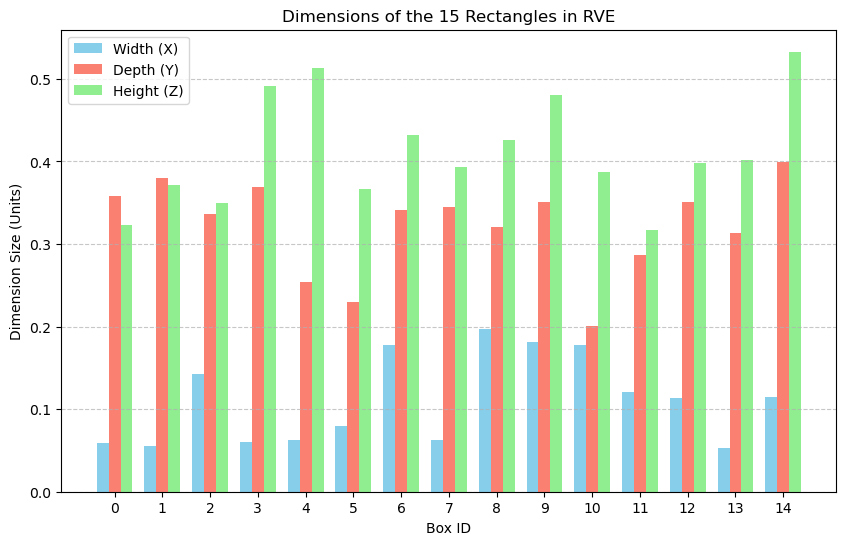

In [ ]:
def generate_random_box_rve(num_boxes=12):
    main_box = Box((0,0,0), (1,1,1))
    voids = []
    
    # Lists to store dimensions for plotting
    actual_widths = []
    actual_depths = []
    actual_heights = []
    
    attempts = 0
    while len(voids) < num_boxes and attempts < 100:
        w = random.uniform(0.05, 0.2)
        d = random.uniform(0.2, 0.4)
        h = random.uniform(0.3, 0.55)
        
        x = random.uniform(0, 1-w)
        y = random.uniform(0, 1-d)
        z = random.uniform(0, 1-h)
        
        void = Box((x, y, z), (x+w, y+d, z+h))
        voids.append(void)
        
        # Store the dimensions that were actually used
        actual_widths.append(w)
        actual_depths.append(d)
        actual_heights.append(h)
        
        attempts += 1

    shape = main_box - Fuse(voids)

    # Identify periodic faces
    shape.faces.Min(X).name = "xmin"
    shape.faces.Max(X).name = "xmax"
    shape.faces.Min(Y).name = "ymin"
    shape.faces.Max(Y).name = "ymax"
    shape.faces.Min(Z).name = "zmin"
    shape.faces.Max(Z).name = "zmax"

    # Apply Periodic Identification with explicit Translations

    shape.faces["xmin"].Identify(shape.faces["xmax"], "x-per", 
                                trafo=Translation((1.0, 0, 0)))

    shape.faces["ymin"].Identify(shape.faces["ymax"], "y-per", 
                                trafo=Translation((0, 1.0, 0)))

    shape.faces["zmin"].Identify(shape.faces["zmax"], "z-per", 
                                trafo=Translation((0, 0, 1.0)))
    # Return both the shape and the dimension data
    return shape, (actual_widths, actual_depths, actual_heights)

# 1. Generate Geometry and Data
num_req = 15
shape, dims = generate_random_box_rve(num_boxes=num_req)
widths, depths, heights = dims

# 2. Plotting the specific distribution for this RVE
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

indices = np.arange(len(widths))
width_bar = 0.25

ax.bar(indices - width_bar, widths, width_bar, label='Width (X)', color='skyblue')
ax.bar(indices, depths, width_bar, label='Depth (Y)', color='salmon')
ax.bar(indices + width_bar, heights, width_bar, label='Height (Z)', color='lightgreen')

ax.set_xlabel('Box ID')
ax.set_ylabel('Dimension Size (Units)')
ax.set_title(f'Dimensions of the {len(widths)} Rectangles in RVE')
ax.set_xticks(indices)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 2. Mesh 
geo = OCCGeometry(shape)

mesh = Mesh(geo.GenerateMesh(maxh=0.08))

Here we define our Finite Element spaces, test and trial functions and our bilinear weak forms.

For linear elasticity, the weak form is given by
$$
a(\mathbf{u}, \mathbf{v}) = \int_\Omega (\mathbb{C} : \boldsymbol{\varepsilon}(\mathbf{u})) : \boldsymbol{\varepsilon}(\mathbf{v}) \, d\Omega \tag{10}
$$
From our decomposition (7), we are instead solving for
$$
\int_\Omega \mathbb{C} : \varepsilon(\mathbf{w}) : \varepsilon(\mathbf{v}) d\Omega
=
-\int_\Omega \mathbb{C} : \bar{\mathbf{E}} : \varepsilon(\mathbf{v}) d\Omega \tag{11}
$$
and applying 6 load cases, one for each Voigt component, for each we solve the equilibrium problem and compute $\langle \mathbf{\sigma} \rangle$.

In [ ]:

# 2. Simple Periodic Space 
V = Periodic(VectorH1(mesh, order=2))
u, v = V.TrialFunction(), V.TestFunction()

# 3. Material Properties
E, nu = 210, 0.2

mu_lame = E / (2*(1+nu))
lam_lame = E*nu / ((1+nu)*(1-2*nu))

def sigma(eps): return 2*mu_lame*eps + lam_lame*Trace(eps)*Id(3)

a = BilinearForm(V)
a += InnerProduct(sigma(Sym(grad(u))), Sym(grad(v))) * dx

with TaskManager():
    pre = Preconditioner(a, "bddc") 
    a.Assemble()

# 4. Homogenisation Loop
magnitude = 0.01
strains = [(0,0), (1,1), (2,2), (1,2), (0,2), (0,1)]
C_eff = np.zeros((6,6))
vol = Integrate(1, mesh)

for idx, (i, j) in enumerate(strains):
    # Setup Macro-Strain E_bar
    vals = [0]*9
    val = magnitude if i == j else 0.5 * magnitude
    vals[i*3 + j] = val; vals[j*3 + i] = val
    E_bar = CF(tuple(vals), dims=(3,3))
    
    f = LinearForm(V)
    f += -InnerProduct(sigma(E_bar), Sym(grad(v))) * dx
    f.Assemble()
    
    gfu = GridFunction(V)
    
    # Solve (The solver handles the floating constant internally via the preconditioner)
    solvers.CG(mat=a.mat, pre=pre, rhs=f.vec, sol=gfu.vec, tol=1e-8, maxsteps=500)
        
    # Stress Calculation - Skipping the manual centering entirely
    # grad(u + constant) == grad(u), so the stiffness is identical
    stress = sigma(E_bar + Sym(grad(gfu)))
    
    for k_idx, (k, l) in enumerate(strains):
        C_eff[idx, k_idx] = (Integrate(stress[k, l], mesh) / vol) / magnitude

C_final = 0.5 * (C_eff + C_eff.T)
print("\nFinal Effective Stiffness Matrix (6x6):")
print(np.round(C_final, 0))

# This code can take upwards of 2 minutes before it will output anything on Google Colab, because it takes a while to 
# generate a BDDC preconditioner.


CG iteration 1, residual = 0.08269159943053547     
CG iteration 2, residual = 1.7761181764373744e-11     
CG iteration 1, residual = 0.04888756290893139     
CG iteration 2, residual = 2.4995354832395328e-11     
CG iteration 1, residual = 0.04312892173723532     
CG iteration 2, residual = 3.0169417093783906e-11     
CG iteration 1, residual = 0.0299408314957539     
CG iteration 2, residual = 7.741744090948107e-12     
CG iteration 1, residual = 0.04676271356119984     
CG iteration 2, residual = 6.21429716803811e-11     
CG iteration 1, residual = 0.0502174348728436     
CG iteration 2, residual = 4.0691607613070095e-11     

Final Effective Stiffness Matrix (6x6):
[[153.  37.  38.   0.  -2.   2.]
 [ 37. 205.  47.  -0.  -1.  -0.]
 [ 38.  47. 212.  -0.  -1.   0.]
 [  0.  -0.  -0.  77.   0.  -1.]
 [ -2.  -1.  -1.   0.  62.  -0.]
 [  2.  -0.   0.  -1.  -0.  58.]]


Now that we've determined an effective stiffness $\mathbb{C}^{\text{eff}}$, we can use it as defined in equation (2) to solve some macroscale problems. 
$$
$$
We will model a macroscale unit box that has the effective stiffness determined from our microscale simulation, and compress it in X, Y and Z directions, to demonstrate the Anisotropy.


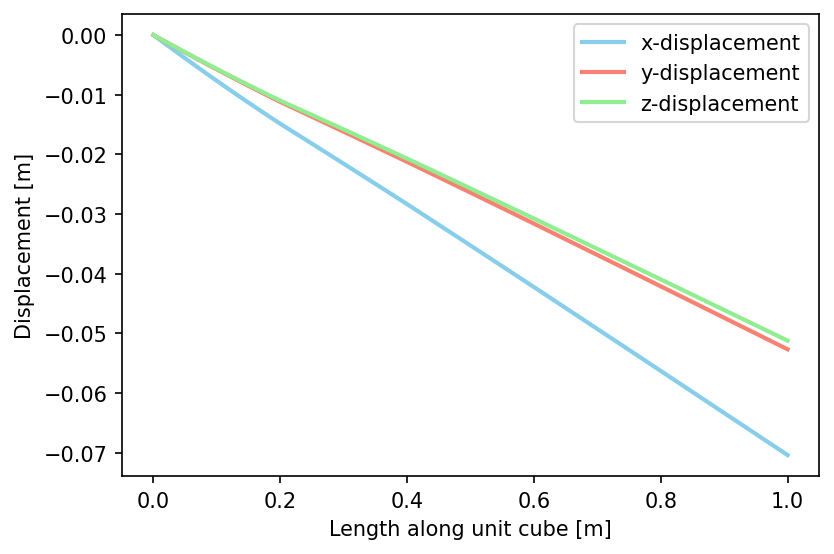

In [ ]:

C = C_final.flatten()
C = tuple(C)
Cauchy_tensor = CoefficientFunction(C, dims=(6, 6))


######################################## CASE 1 ########################################

geometry = Box((0,0,0), (1,1,1))
geometry.faces.Max(X).name = "force"
geometry.faces.Min(X).name = "fix"
mesh_macro = geometry.GenerateMesh(maxh=0.2).Curve(3)


# 2. Use the corrected VoigtStrain (matches your homogenization loop order)
def VoigtStrain(u):
    eps = Sym(grad(u))
    # Order: 11, 22, 33, 23, 13, 12 (Matches your homogenization loop)
    return CF((eps[0,0], eps[1,1], eps[2,2], 
               eps[1,2], eps[0,2], eps[0,1]))

V_macro = VectorH1(mesh_macro, order=2, dirichlet="fix")
u_macro, v_macro = V_macro.TrialFunction(), V_macro.TestFunction()
gfu = GridFunction(V_macro)


# 3. Assemble the BilinearForm
a_macro = BilinearForm(V_macro)
eps_u = VoigtStrain(u_macro)
eps_v = VoigtStrain(v_macro)

# Use C_tensor * eps_u (Matrix-Vector multiplication)
a_macro += InnerProduct(Cauchy_tensor * eps_u, eps_v) * dx
pre = Preconditioner(a_macro, "bddc")
a_macro.Assemble()


force = CF((-10, 0, 0))
f_macro = LinearForm(force * v_macro * ds("force")).Assemble()

solvers.CG(mat=a_macro.mat, pre=pre, rhs=f_macro.vec, sol=gfu.vec, tol=1e-8, maxsteps=500, printrates=False)

ea = { "euler_angles" : [-70,5,30] }

heights = np.linspace(0,1,50)
val_x = []

for x in heights:
        val = gfu(mesh(x,0,0))
        val_x.append(val[0])



################################ CASE 2 ########################################

geometry = Box((0,0,0), (1,1,1))
geometry.faces.Max(Y).name = "force"
geometry.faces.Min(Y).name = "fix"
mesh_macro = geometry.GenerateMesh(maxh=0.2).Curve(3)
def VoigtStrain(u):
    eps = Sym(grad(u))
    return CF((eps[0,0], eps[1,1], eps[2,2], 
               eps[1,2], eps[0,2], eps[0,1]))

V_macro = VectorH1(mesh_macro, order=2, dirichlet="fix")
u_macro, v_macro = V_macro.TrialFunction(), V_macro.TestFunction()
gfu = GridFunction(V_macro)
a_macro = BilinearForm(V_macro)
eps_u = VoigtStrain(u_macro)
eps_v = VoigtStrain(v_macro)
a_macro += InnerProduct(Cauchy_tensor * eps_u, eps_v) * dx
pre = Preconditioner(a_macro, "bddc")
a_macro.Assemble()
force = CF((0, -10, 0))
f_macro = LinearForm(force * v_macro * ds("force")).Assemble()
solvers.CG(mat=a_macro.mat, pre=pre, rhs=f_macro.vec, sol=gfu.vec, tol=1e-8, maxsteps=500, printrates=False)

val_y = []

for y in heights:
        val = gfu(mesh(0,y,0))
        val_y.append(val[1])

######################################## CASE 3 ########################################

geometry = Box((0,0,0), (1,1,1))
geometry.faces.Max(Z).name = "force"
geometry.faces.Min(Z).name = "fix"
mesh_macro = geometry.GenerateMesh(maxh=0.2).Curve(3)
def VoigtStrain(u):
    eps = Sym(grad(u))
    return CF((eps[0,0], eps[1,1], eps[2,2], 
               eps[1,2], eps[0,2], eps[0,1]))

V_macro = VectorH1(mesh_macro, order=2, dirichlet="fix")
u_macro, v_macro = V_macro.TrialFunction(), V_macro.TestFunction()
gfu = GridFunction(V_macro)
a_macro = BilinearForm(V_macro)
eps_u = VoigtStrain(u_macro)
eps_v = VoigtStrain(v_macro)

a_macro += InnerProduct(Cauchy_tensor * eps_u, eps_v) * dx
pre = Preconditioner(a_macro, "bddc")
a_macro.Assemble()
force = CF((0, 0, -10))
f_macro = LinearForm(force * v_macro * ds("force")).Assemble()
solvers.CG(mat=a_macro.mat, pre=pre, rhs=f_macro.vec, sol=gfu.vec, tol=1e-8, maxsteps=500, printrates=False)

val_z = []

for z in heights:
        val = gfu(mesh(0,0,z))
        val_z.append(val[2])

plt.figure(figsize=(6,4), dpi=150)
plt.plot(heights, val_x, label='x-displacement', color='skyblue', lw=2)
plt.plot(heights, val_y, label='y-displacement', color='salmon', lw=2)
plt.plot(heights, val_z, label='z-displacement', color='lightgreen', lw=2)
plt.xlabel('Length along unit cube [m]')
plt.ylabel('Displacement [m]')
plt.legend()
plt.show()


We have shown that the effective stiffness is lowest in one direction, and highest in another. Since we are using linear elasticity for our microscale and macroscale, the applied macroscale strain $\bar{E}$ to the microscale model does not matter, since it is a linear model, and consequently we don't need any HMM iterations. 
$$
$$
However, if we were to use different physics, like a non-linear elastic model, then we would need to run a new microscale simulation for every new strain in our macroscale model. Also, we have assumed that the microscale model is the same at every point in our macroscale mesh, however if we wanted to introduce heterogeneity, then our stiffness tensor would become functions of space,
$$
\mathbb{C} = \mathbb{C}(x,y,z), \tag{12}
$$
where each component of the stiffness tensor is a smooth function that varies spatially.